## On Policy Monte Carlo Control example of Maze

In [1]:
USE {
    repositories {
        mavenCentral()
        maven("https://central.sonatype.com/repository/maven-snapshots/")
    }
    dependencies {
        implementation("io.github.kotlinrl:envs:0.1.0-SNAPSHOT")
    }
}
%use dataframe
%use kandy

In [2]:
import io.github.kotlinrl.core.*
import io.github.kotlinrl.envs.*
import java.io.*

Let's define our hyper-parameters to control training and learning

In [3]:
val maxStepsPerEpisode = 500
val trainingEpisodes = 1000
val testEpisodes = 30
val initialEpsilon = 1.0
val epsilonDecayRate = 0.997
val minEpsilon = 0.05
val gamma = 0.99
val fileName = "MazeOnPolicyMonteCarloControl.csv"

Creating the following
- Maze = ```Env<IntArray, Int, MultiDiscrete, Discrete>```
- ```StateActionListProvider``` to define the list of Actions for any State.  Maxe only allows
    - Actions
        - UP = 0
        - Right = 1
        - DOWN = 2
        - LEFT = 3
- The ```QTable``` used to capture training information
    - Monte Carlo Control must wait until the end of each Episode to update the ```QTable```

In [4]:
val env = Maze(render = true)
val stateActionListProvider = StateActionListProvider<IntArray, Int> { listOf(0, 1, 2, 3) }

Next we create the training Agent using the Monte Carlo Control
- We use an Epsilon Greedy Policy with a decaying epsilon to encourage convergence (experimenting with a constant epsilon would lead to different results) for the exploration factor
- The Epsilon Greedy Policy randomly chooses a number.
    - If it is less than the epsilon value it uses a Random Policy selection
    - Otherwise it uses a Greedy Policy to select the best action from the ```QTable```

The Trainer uses the env and agent with a max steps per episode and trains for the number of training episodes
- We register the ```OnPolicyMonteCarloControl``` with a ```gamma``` value as a ```EpisodeCallback``` so that when the episode completes, it updates the ```QTable```
- We also register the episode logger
- We then train for the number of training episodes
- When training completes we save the ```QTable``` for later use

In [ ]:
val trainingQtable = QTable(5, 5, 4)
if(File(fileName).exists()) {
    trainingQtable.load(fileName)
    println("QTable loaded from file")
}
val trainingAgent = agent(
    id = "training",
    policy = epsilonGreedyPolicy(
        stateActionListProvider = stateActionListProvider,
        explorationFactor = decayingEpsilon(
            factor = initialEpsilon,
            minFactor = minEpsilon,
            decayRate = epsilonDecayRate
        ),
        qTable = trainingQtable
    )
)
val trainer = episodicTrainer(
    env = env,
    agent = trainingAgent,
    maxStepsPerEpisode = maxStepsPerEpisode,
    callbacks = listOf(
        onPolicyMonteCarloControl(trainingQtable, gamma),
        object : EpisodeCallback<IntArray, Int> {
            override fun onEpisodeStart(episode: Int) {
                if (episode % 10 == 0) println("Starting episode $episode")
            }
        }
    )
)
println("Starting training")
val training = trainer.train(trainingEpisodes)
trainingQtable.save(fileName)

Once training is complete, we create the following
- A new ```QTable``` with the same shape, and load the training data
- A new test ```Agent``` using a ```GreedyPolicy``` against the ```QTable``` with loaded weights
- The Greedy Policy always chooses the best action from the ```QTable```
    - It performs the best action given the state: ```(playerSum, dealerSum, usableAce)```

We then test for the number of testing episodes to compare the episode results (i.e. the average reward achieved)

In [6]:
val testingQtable = QTable(5, 5, 4)
testingQtable.load(fileName)

In [ ]:
val recordEnv = RecordVideo(env = env, folder = "videos/maze_on_policy_mcc", 10)
val testingAgent = agent(
    id = "testing",
    policy = greedyPolicy(
        qTable = testingQtable
    )
)
val tester = episodicTrainer(
    env = recordEnv,
    agent = testingAgent,
    maxStepsPerEpisode = maxStepsPerEpisode,
    callbacks = listOf(object : EpisodeCallback<IntArray, Int> {
        override fun onEpisodeStart(episode: Int) {
            if (episode % 10 == 0) println("Starting episode $episode")
        }
    })
)
println("Starting testing")
val test = tester.train(testEpisodes)

Compare the average results.

In [ ]:
println("Training Results: ${training.episodeRewards.sum() / training.episodeRewards.size}")
println("Test Results: ${test.episodeRewards.sum() / test.episodeRewards.size}")
val folder = File(recordEnv.folder)
for(file in folder.listFiles()!!.filter { it.isDirectory }) {
    displayVideo(File(folder, file.name))
}

Let's plot our results

In [9]:
val format: String = "%6.2f"
val actionSymbols = mapOf(0 to "↑", 1 to "→", 2 to "↓", 3 to "←")
val shape = testingQtable.shape

val stateDf = buildList {
    for (row in 0 until shape[0]) {
        for (col in 0 until shape[1]) {
            val state = intArrayOf(row, col)
            val valueRaw = testingQtable.maxValue(state)
            val valueStr = format.format(valueRaw)
            val action = testingQtable.bestAction(state)
            val arrow = actionSymbols[action] ?: "?"

            // Two rows per cell: one for Value, one for Policy
            add(mapOf("x" to col, "y" to -row, "value" to valueRaw, "label" to valueStr, "type" to "Value"))
            add(mapOf("x" to col, "y" to -row, "value" to valueRaw, "label" to arrow, "type" to "Policy"))
        }
    }
}.flatMap { it.entries }.groupBy({ it.key}, { it.value }).toDataFrame()

plotGrid(stateDf.groupBy("type").map { (typeLabel, group) ->
    group.plot {
        layout.title = typeLabel[0]?.toString() ?: ""

        tiles {
            x("x")
            y("y")
            fillColor("value") {
                scale = continuous(Color.BLUE..Color.WHITE)
            }
            borderLine {
                width = 0.5
                color = Color.BLACK
            }
        }


        text {
            x("x")
            y("y")
            label("label")
            font {
                size = if (typeLabel[0] == "Policy") 18.0 else 6.0
                color = Color.BLACK
            }
        }

        x.axis.name = "x"
        y.axis.name = "y"
    }
})

<head>
 <meta charset="UTF-8">
 <style> html, body { margin: 0; overflow: hidden; } </style>
 <script type="text/javascript" data-lets-plot-script="library" src="https://cdn.jsdelivr.net/gh/JetBrains/lets-plot@v4.5.1/js-package/distr/lets-plot.min.js"></script>
 </head>
 <body>
 <div id="16KCds"></div>
 <script type="text/javascript" data-lets-plot-script="plot">
 
 (function() {
 // ----------
 
 var plotSpec={
"layout":{
"name":"grid",
"ncol":2,
"nrow":1,
"fit":true,
"align":false
},
"figures":[{
"ggtitle":{
"text":"Value"
},
"mapping":{
},
"data":{
"x":[0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0],
"y":[0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-2.0,-2.0,-2.0,-2.0,-2.0,-3.0,-3.0,-3.0,-3.0,-3.0,-4.0,-4.0,-4.0,-4.0,-4.0],
"label":["-48.93","-48.37","-50.16","-50.30","-54.61","-47.91","-51.32","-62.13","-52.59","-60.00","-44.20","-56.03","-57.86","-55.00","-62.39","-39.49","-60.63","-12.06"," -7.37"," -1.00","-33.13","-26.10","-19.56"," -1.00"," 0.00"],
"value":[-48.92774156905342,-48.36924844573334,-50.15845351755905,-50.30187519941696,-54.606010081633556,-47.90762524073613,-51.319887540225295,-62.13354843183107,-52.59349402539831,-60.004326029228125,-44.20215965289285,-56.03401941535002,-57.86490603331446,-54.99851124595521,-62.38699688360916,-39.48561255315349,-60.63177881746735,-12.057720074499189,-7.370583843253996,-1.0,-33.133095451395896,-26.095689612850883,-19.55502780023578,-1.0,0.0]
},
"kind":"plot",
"scales":[{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"fill",
"scale_mapper_kind":"color_gradient",
"high":"#ffffff",
"low":"#5470c6",
"limits":[null,null]
},{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"x",
"name":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"name":"y",
"limits":[null,null]
}],
"layers":[{
"mapping":{
"x":"x",
"y":"y",
"fill":"value"
},
"stat":"identity",
"size":0.5,
"color":"#000000",
"sampling":"none",
"inherit_aes":false,
"position":"identity",
"geom":"tile",
"data":{
}
},{
"mapping":{
"x":"x",
"y":"y",
"label":"label"
},
"stat":"identity",
"size":6.0,
"color":"#000000",
"sampling":"none",
"inherit_aes":false,
"position":"identity",
"geom":"text",
"data":{
}
}],
"data_meta":{
"series_annotations":[{
"type":"int",
"column":"x"
},{
"type":"int",
"column":"y"
},{
"type":"float",
"column":"value"
},{
"type":"str",
"column":"label"
}]
},
"spec_id":"3"
},{
"ggtitle":{
"text":"Policy"
},
"mapping":{
},
"data":{
"x":[0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0],
"y":[0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-2.0,-2.0,-2.0,-2.0,-2.0,-3.0,-3.0,-3.0,-3.0,-3.0,-4.0,-4.0,-4.0,-4.0,-4.0],
"label":["↓","←","←","←","←","↓","↑","↓","↑","↑","↓","↑","→","↑","↑","↓","↑","→","→","↓","→","→","↑","→","↑"],
"value":[-48.92774156905342,-48.36924844573334,-50.15845351755905,-50.30187519941696,-54.606010081633556,-47.90762524073613,-51.319887540225295,-62.13354843183107,-52.59349402539831,-60.004326029228125,-44.20215965289285,-56.03401941535002,-57.86490603331446,-54.99851124595521,-62.38699688360916,-39.48561255315349,-60.63177881746735,-12.057720074499189,-7.370583843253996,-1.0,-33.133095451395896,-26.095689612850883,-19.55502780023578,-1.0,0.0]
},
"kind":"plot",
"scales":[{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"fill",
"scale_mapper_kind":"color_gradient",
"high":"#ffffff",
"low":"#5470c6",
"limits":[null,null]
},{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"x",
"name":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"name":"y",
"limits":[null,null]
}],
"layers":[{
"mapping":{
"x":"x",
"y":"y",
"fill":"value"
},
"stat":"identity",
"size":0.5,
"color":"#000000",
"sampling":"none",
"inherit_aes":false,
"position":"identity",
"geom":"tile",
"data":{
}
},{
"mapping":{
"x":"x",
"y":"y",
"label":"

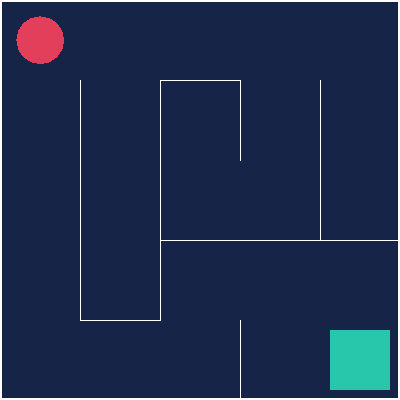

In [10]:
import java.io.File
import javax.imageio.ImageIO
import java.awt.image.BufferedImage

val pngFile = File(recordEnv.folder).listFiles()?.sorted()?.first()?.listFiles()?.sorted()?.first()

val image: BufferedImage = ImageIO.read(pngFile)
image